> **Branch:** `feature/stage7-evaluation`  
> **Author:** Theertha  
> ⚠️ **Before running:** Make sure you have already run `stage00_dataset_generator.ipynb` in the same Colab session so that `/content/dataset` and all shared variables are available.


---
# STAGE 7 — Model Evaluation & Comparison
**Author: Theertha**  
**Branch: feature/stage7-evaluation**

---

In [32]:
# ============================================================
# STAGE 7 — MODEL EVALUATION & COMPARISON
# Author: Theertha
# ============================================================

from sklearn.metrics import (classification_report, confusion_matrix,
                              f1_score, accuracy_score,
                              precision_score, recall_score)
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

symbol_names = list(class_mapping.values())
models = {
    'SVM'           : svm_model,
    'KNN'           : knn_model,
    'Decision Tree' : dt_model
}

results = {}

for model_name, model in models.items():
    y_pred = model.predict(X_test)
    results[model_name] = {
        'Accuracy'  : round(accuracy_score(y_test, y_pred), 4),
        'Macro F1'  : round(f1_score(y_test, y_pred, average='macro'), 4),
        'Precision' : round(precision_score(y_test, y_pred, average='macro'), 4),
        'Recall'    : round(recall_score(y_test, y_pred, average='macro'), 4),
        'y_pred'    : y_pred
    }

# Comparison Table
df_results = pd.DataFrame({
    k: {m: v for m, v in v.items() if m != 'y_pred'}
    for k, v in results.items()
}).T

print("\n📊 Model Comparison Table")
print(df_results.to_string())


📊 Model Comparison Table
               Accuracy  Macro F1  Precision  Recall
SVM              0.9929    0.9929     0.9933  0.9929
KNN              0.9886    0.9886     0.9888  0.9886
Decision Tree    0.9271    0.9274     0.9286  0.9271


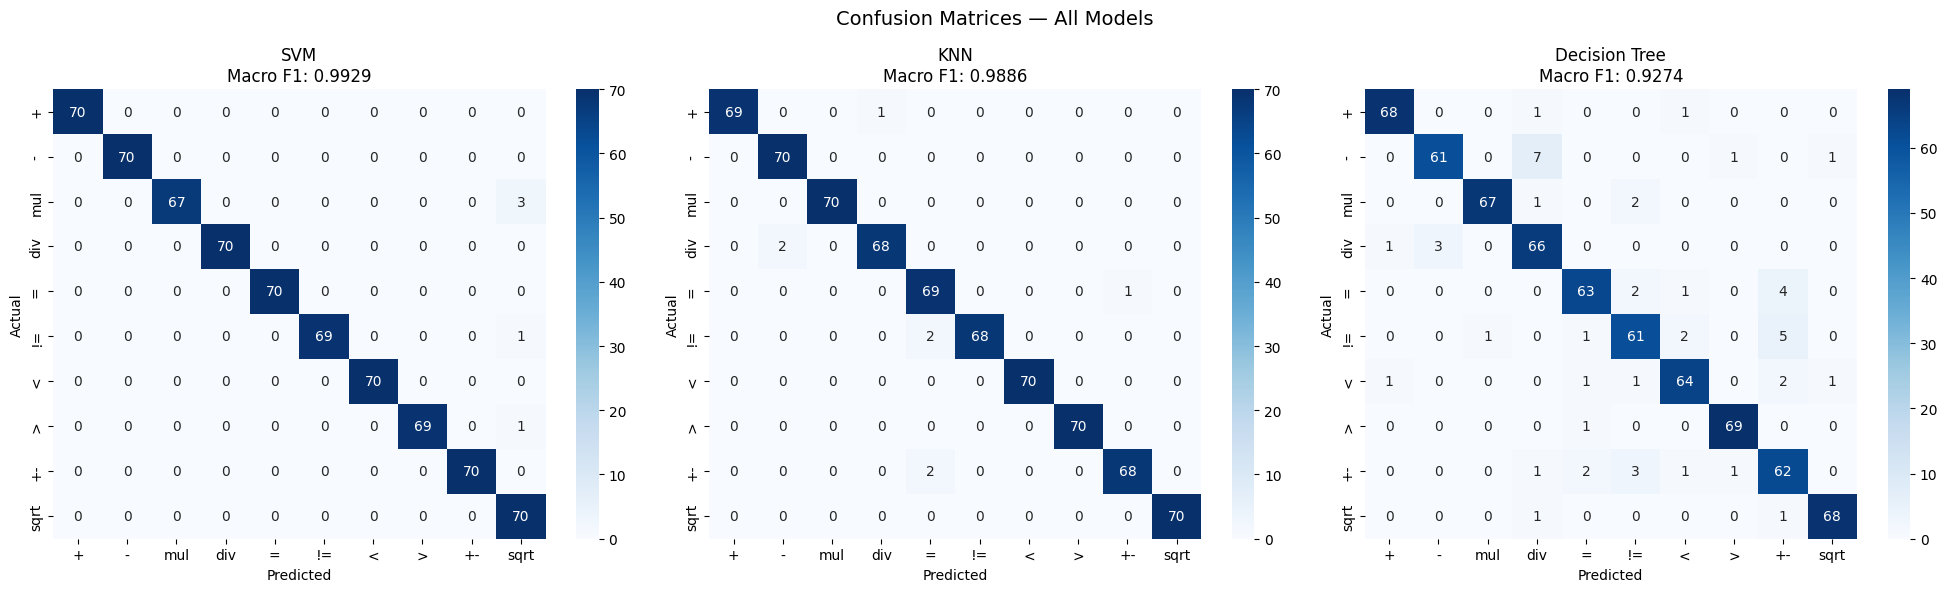

In [33]:
# ── Confusion Matrices for all 3 models ───────────────────
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle('Confusion Matrices — All Models', fontsize=14)

for ax, (model_name, result) in zip(axes, results.items()):
    cm = confusion_matrix(y_test, result['y_pred'])
    sns.heatmap(
        cm, annot=True, fmt='d', cmap='Blues',
        xticklabels=symbol_names,
        yticklabels=symbol_names,
        ax=ax
    )
    ax.set_title(f'{model_name}\nMacro F1: {result["Macro F1"]}', fontsize=12)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=150)
plt.show()

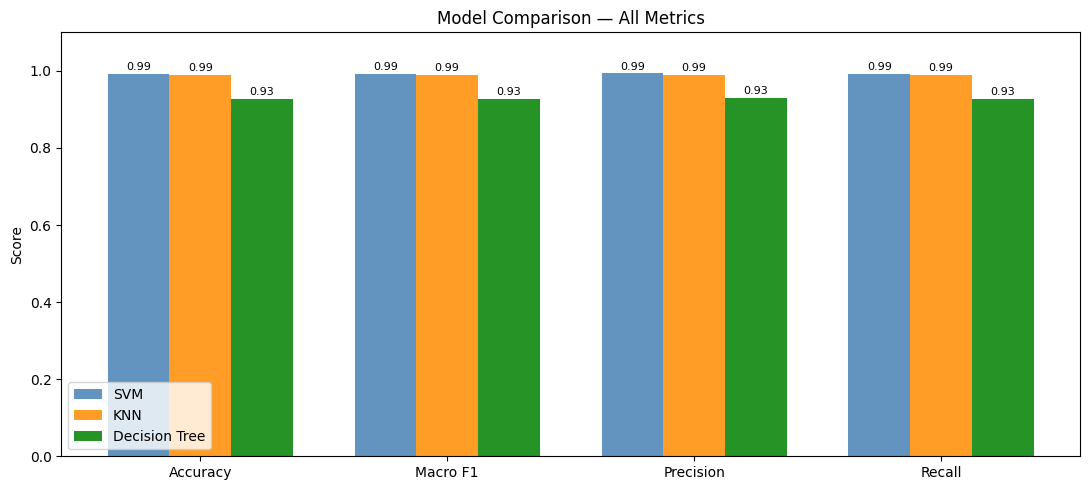

Stage 7 Complete ✅


In [34]:
# ── Bar chart comparison ──────────────────────────────────
metrics = ['Accuracy', 'Macro F1', 'Precision', 'Recall']
x = np.arange(len(metrics))
width = 0.25
colors = ['steelblue', 'darkorange', 'green']

fig, ax = plt.subplots(figsize=(11, 5))
for i, (model_name, result) in enumerate(results.items()):
    vals = [result[m] for m in metrics]
    bars = ax.bar(x + i*width, vals, width,
                  label=model_name, color=colors[i], alpha=0.85)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f'{v:.2f}', ha='center', va='bottom', fontsize=8)

ax.set_xticks(x + width)
ax.set_xticklabels(metrics)
ax.set_ylim(0, 1.1)
ax.set_ylabel('Score')
ax.set_title('Model Comparison — All Metrics')
ax.legend()
plt.tight_layout()
plt.savefig('model_comparison_chart.png', dpi=150)
plt.show()
print("Stage 7 Complete ✅")